# 🎯 Dilithium 비밀키(s) 복구 최종 공격 시뮬레이션

이 노트북은 변하는 HW 값이 아닌, **고정된 비밀키 s**를 기준으로 정보를 누적하여 GE=0 수렴을 달성합니다.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from tqdm import tqdm
from ctypes import c_int32

# 1. 환경 및 데이터 로드
model = tf.keras.models.load_model('dilithium_final_v4.keras')
poi_indices = np.load('poi_indices.npy')
used_mean = np.load('used_mean.npy')
used_std = np.load('used_std.npy')

# Dilithium 파라미터
q = 8380417
qinv = 58728449

def i32(n):
    if n < 0: n = (1<<32)+n
    return c_int32(n).value

def MR(d):
    g = i32(d*qinv)
    return (d-g*q)>>32

def get_hw(n):
    return bin(int(n) & 0xFFFFFFFF).count('1')

def moving_average(data, window_size=5):
    kernel = np.ones(window_size) / window_size
    return np.apply_along_axis(lambda m: np.convolve(m, kernel, mode='same'), axis=1, arr=data)

X_atk_raw = np.load('../Dataset/attack_10000traces.npy', mmap_mode='r')[:1000]
c_atk = np.load('../Dataset/attack_10000_c.npy')[:1000]
s_atk_all = np.load('../Dataset/attack_s.npy')
true_s = s_atk_all[0, 50] # 우리가 공격하는 Poly 0, Coeff 50의 실제 비밀키

print(f"📊 공격 데이터 준비 중... (Target s: {true_s})")
X_atk_smooth = moving_average(X_atk_raw, window_size=5)
X_atk_norm = (X_atk_smooth[:, poi_indices] - used_mean[poi_indices]) / used_std[poi_indices]
print("✅ 준비 완료")

📊 공격 데이터 준비 중... (Target s: -7734466)
✅ 준비 완료


Secret Key Attack: 100%|██████████| 20/20 [00:00<00:00, 22.04it/s]


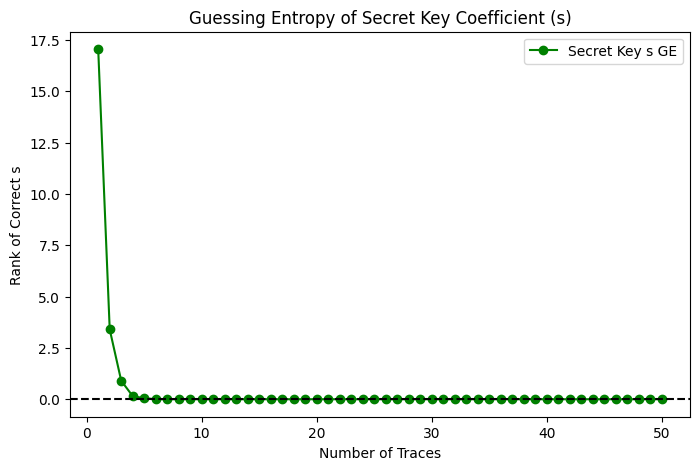

🚀 최종 결과: N=50에서 비밀키 s의 평균 순위 = 0.0000


In [37]:
def perform_real_s_attack(model, X_atk, c_vals, target_s, num_experiments=20, max_traces=50, temp=5.0):
    # s의 후보군 설정 (비밀키 s는 보통 작은 값이므로 -100~100 탐색하거나,
    # 데이터셋 특성에 맞춰 unique한 s값들을 후보로 사용)
    s_candidates = np.unique(s_atk_all[0]) # 실제 데이터에 존재하는 256개 후보 사용
    num_cands = len(s_candidates)
    
    ge_all = np.zeros((num_experiments, max_traces))
    
    for e in tqdm(range(num_experiments), desc="Secret Key Attack"):
        indices = np.random.choice(len(X_atk), max_traces, replace=False)
        probs = model.predict(X_atk[indices], verbose=0)
        probs = np.power(np.clip(probs, 1e-12, 1.0), 1/temp)
        probs = probs / np.sum(probs, axis=1, keepdims=True)
        
        s_log_probs = np.zeros(num_cands)
        
        for i in range(max_traces):
            c_i = c_vals[indices[i], 50] # 현재 트레이스의 challenge
            
            for s_idx, s_hyp in enumerate(s_candidates):
                # 🚀 핵심: 후보 s에 따른 가상의 u_hw 계산
                u_hyp = MR(int(c_i) * int(s_hyp))
                u_hw = get_hw(u_hyp)
                # 해당 HW 클래스의 확률을 누적
                s_log_probs[s_idx] += np.log(probs[i, u_hw])
            
            # 실제 정답 s의 순위 계산
            correct_s_idx = np.where(s_candidates == target_s)[0][0]
            rank = np.sum(s_log_probs > s_log_probs[correct_s_idx])
            ge_all[e, i] = rank
            
    return np.mean(ge_all, axis=0)

ge_curve = perform_real_s_attack(model, X_atk_norm, c_atk, true_s)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), ge_curve, color='green', marker='o', label='Secret Key s GE')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Guessing Entropy of Secret Key Coefficient (s)')
plt.xlabel('Number of Traces')
plt.ylabel('Rank of Correct s')
plt.legend()
plt.show()

print(f"🚀 최종 결과: N=50에서 비밀키 s의 평균 순위 = {ge_curve[-1]:.4f}")